# floodar — exploring the NYC 1-foot DEM

Defaults to the whole-city **COG** at `../data/nyc_dem_1ft_int_cog.tif` (build it with
`floodar cog` — see `data/README.md`). If that file isn't present, the notebook builds a
small synthetic tile so it still runs.

The DEM is EPSG:2263, whole feet NAVD88, `uint16`. **`0` = water / outside-city /
0-ft ground** (no nodata tag): mask it for land relief, but keep it for flooding (it's
the water source). The full raster is 24.7 B pixels, so we always work over an **AOI**.

Run: `uv sync --extra notebooks` then `uv run jupyter lab`.

In [1]:
from pathlib import Path
import numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from floodar import io, inspect, viz, flood, query

DEM_PATH = Path('../data/nyc_dem_1ft_int_cog.tif')   # whole-city NYC COG
REAL = DEM_PATH.exists()

if not REAL:
    import rasterio
    from rasterio.transform import from_origin
    h = np.zeros((400, 400), 'float32'); xs = np.arange(400)
    h += (xs / 400 * 50)[None, :]          # coastal ramp, 0 -> 50 ft W->E
    h[150:200, 280:340] = 2.0               # walled interior depression (dry land)
    DEM_PATH = Path('_synthetic_dem.tif')
    with rasterio.open(DEM_PATH, 'w', driver='GTiff', height=400, width=400,
            count=1, dtype='float32', crs='EPSG:2263',
            transform=from_origin(980000, 200000, 1, 1)) as d:
        d.write(h, 1)
    print('no COG found — using synthetic tile')

io.describe(DEM_PATH)

RasterInfo(path='../data/nyc_dem_1ft_int_cog.tif', driver='GTiff', crs='EPSG:2263', epsg=2263, width=158100, height=156100, count=1, dtype='uint16', nodata=None, res=(1.0, 1.0), bounds=(910719.3, 119060.67499999999, 1068819.3, 275160.675), units='US survey foot')

## Pick an area of interest

Whole-city native reads are 24.7 B pixels — always window to an AOI. Default here is
**Lower Manhattan** (lon/lat, reprojected to EPSG:2263). Swap in your own bbox, e.g.
the Rockaways `[-73.83,-73.74],[40.56,40.60]` or Red Hook `[-74.02,-73.99],[40.66,40.69]`.

In [2]:
if REAL:
    from rasterio.warp import transform
    lons, lats = [-74.020, -73.997], [40.700, 40.722]   # Lower Manhattan
    xs, ys = transform('EPSG:4326', 'EPSG:2263', lons, lats)
    bounds = (min(xs), min(ys), max(xs), max(ys))
else:
    bounds = None   # synthetic tile is already small

arr, tr = io.read(DEM_PATH, bounds=bounds, max_size=2500)   # decimated window read
cell = abs(tr.a)
print(f'window {arr.shape}, cell = {cell:.2f} ft')

window (2500, 1989), cell = 3.21 ft


## Land-only stats + histogram

Mask `0` so water / outside-city don't swamp the distribution (~65% of the grid citywide).

{'count': 3545216, 'nodata_count': 1427284, 'min': 1.0, 'max': 53.0, 'mean': 16.124055862426758, 'std': 9.228601455688477, 'p1': 2.0, 'p5': 5.0, 'p25': 9.0, 'p50': 14.0, 'p75': 21.0, 'p95': 35.0, 'p99': 40.0}


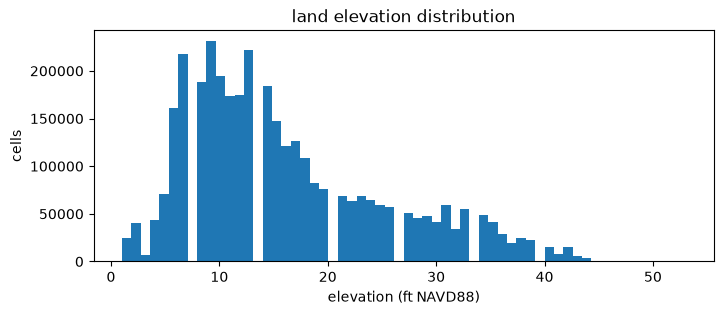

In [3]:
land = io.read(DEM_PATH, bounds=bounds, max_size=2500, mask_values=0)[0]
print(inspect.stats(land).as_dict())

counts, edges = inspect.histogram(land, bins=60)
plt.figure(figsize=(8, 3)); plt.bar(edges[:-1], counts, width=np.diff(edges), align='edge')
plt.xlabel('elevation (ft NAVD88)'); plt.ylabel('cells'); plt.title('land elevation distribution');

## Shaded relief (water in blue)

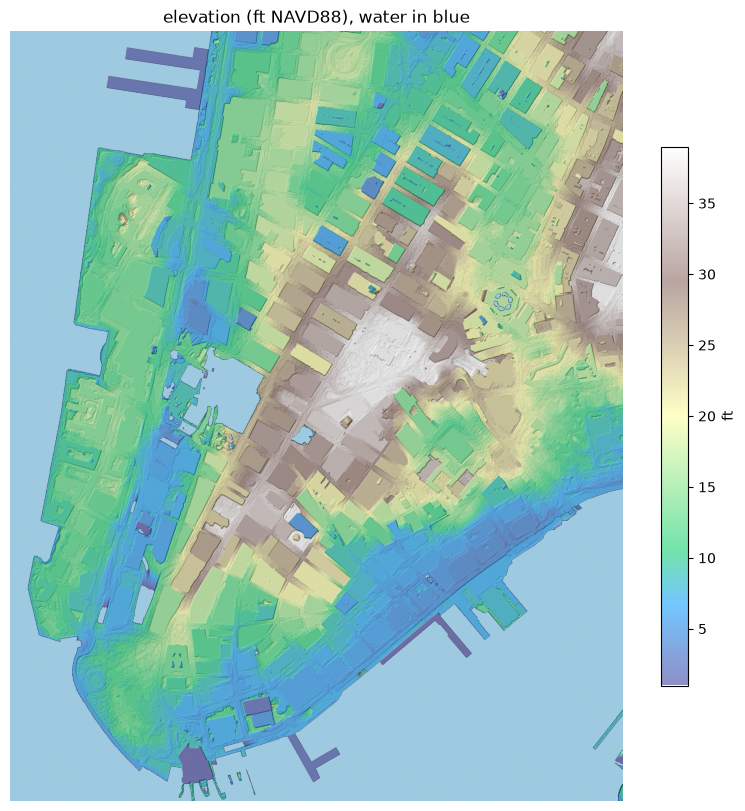

In [4]:
elev = np.ma.filled(arr, 0.0); is_land = elev > 0
base = np.ma.masked_where(~is_land, elev)
hs = viz.hillshade(base, cellsize=cell, z_factor=2.0)
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(hs, cmap='gray')
im = ax.imshow(base, cmap='terrain', alpha=0.55, vmax=np.percentile(elev[is_land], 98))
ax.imshow(np.ma.masked_where(is_land, elev), cmap=ListedColormap(['#9ecae1']))  # water
ax.set_title('elevation (ft NAVD88), water in blue'); ax.axis('off')
plt.colorbar(im, ax=ax, shrink=0.7, label='ft');

## Flood scenarios (feet NAVD88)

`baseline=0` treats the 0-ft water as pre-existing (it seeds inundation and is excluded
from *dry-land* stats). Reference levels: MHHW ~2.5 ft; Hurricane Sandy peak surge at the
Battery ~11 ft.

  3.0 ft  ->  total    352.0 ac | dry-land     15.2 ac | max depth 2.0 ft
  6.0 ft  ->  total    412.1 ac | dry-land     75.3 ac | max depth 5.0 ft
  9.0 ft  ->  total    548.6 ac | dry-land    211.8 ac | max depth 8.0 ft
 11.0 ft  ->  total    631.7 ac | dry-land    294.9 ac | max depth 10.0 ft


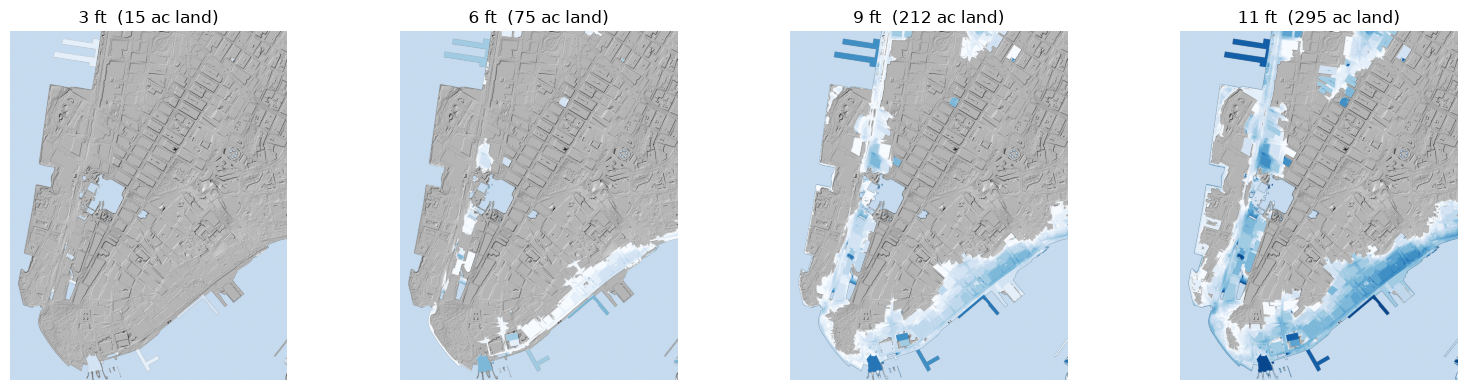

In [5]:
levels = [3, 6, 9, 11]
results = flood.scenarios(arr, levels, cell_size=cell, connected=True, baseline=0.0)
for r in results:
    s = r.summary()
    print(f"{s['water_level']:5.1f} ft  ->  total {s['flooded_area_acres']:8.1f} ac | "
          f"dry-land {s['land_flooded_acres']:8.1f} ac | max depth {s['max_depth']:.1f} ft")

fig, axes = plt.subplots(1, len(levels), figsize=(4*len(levels), 4))
for ax, r in zip(axes, results):
    ax.imshow(hs, cmap='gray')
    ax.imshow(np.ma.masked_where(is_land, elev), cmap=ListedColormap(['#c6dbef']))   # existing water
    depth = np.ma.masked_where(~r.newly_flooded, np.ma.filled(r.depth, 0.0))         # newly-flooded land
    ax.imshow(depth, cmap='Blues', vmin=0, vmax=max(levels))
    ax.set_title(f'{r.water_level:.0f} ft  ({r.land_flooded_area_acres:.0f} ac land)'); ax.axis('off')
plt.tight_layout();

## Elevation profile (cross-section)

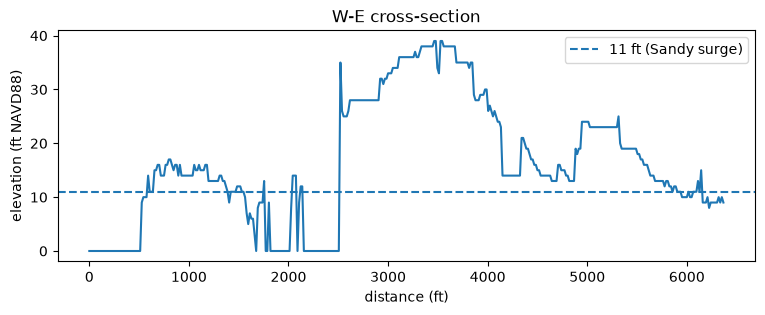

In [6]:
b = io.describe(DEM_PATH).bounds if not REAL else bounds
start = (b[0] + 5, (b[1] + b[3]) / 2)
end   = (b[2] - 5, (b[1] + b[3]) / 2)
dist, elevs = query.profile(DEM_PATH, start, end, n=400, src_epsg=2263)
plt.figure(figsize=(9, 3)); plt.plot(dist, elevs)
plt.axhline(11, color='C0', ls='--', label='11 ft (Sandy surge)'); plt.legend()
plt.xlabel('distance (ft)'); plt.ylabel('elevation (ft NAVD88)'); plt.title('W-E cross-section');